In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from keras.models import Sequential
from keras import layers
from keras.backend import clear_session
from keras.preprocessing.text import Tokenizer
from keras.layers import Activation, Dense, Reshape 
import numpy as np
from keras import backend as K
import matplotlib.pyplot as plt
import pandas as pd
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout, Conv1D, GlobalMaxPooling1D
from keras.models import load_model
from numpy import asarray
from numpy import save
from numpy import load
from numpy import load
plt.style.use('ggplot')

In [ ]:
!wget http://files.srl.inf.ethz.ch/data/js_dataset.tar.gz

--2022-08-17 12:05:35--  http://files.srl.inf.ethz.ch/data/js_dataset.tar.gz
Resolving files.srl.inf.ethz.ch (files.srl.inf.ethz.ch)... 129.132.85.35
Connecting to files.srl.inf.ethz.ch (files.srl.inf.ethz.ch)|129.132.85.35|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.sri.inf.ethz.ch/data/js_dataset.tar.gz [following]
--2022-08-17 12:05:36--  https://files.sri.inf.ethz.ch/data/js_dataset.tar.gz
Resolving files.sri.inf.ethz.ch (files.sri.inf.ethz.ch)... 129.132.85.35
Connecting to files.sri.inf.ethz.ch (files.sri.inf.ethz.ch)|129.132.85.35|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2632133476 (2.5G) [application/x-gzip]
Saving to: ‘js_dataset.tar.gz’

js_dataset.tar.gz   100%[===================>]   2.45G  12.3MB/s    in 3m 33s  

2022-08-17 12:09:11 (11.8 MB/s) - ‘js_dataset.tar.gz’ saved [2632133476/2632133476]

unzip:  cannot find or open sentiment labelled sentences.zip, sentiment labelled sent

In [ ]:
!unzip "js_dataset.tar.gz"

Archive:  js_dataset.tar.gz
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of js_dataset.tar.gz or
        js_dataset.tar.gz.zip, and cannot find js_dataset.tar.gz.ZIP, period.


In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

In [ ]:
def Read_data_and_split():
    data = pd.read_csv("socialmedia_disaster.csv") #  9346 Samples
#     filepath_dict = {'yelp':   'data/yelp_labelled.txt',
#                  'amazon': 'data/amazon_cells_labelled.txt',
#                  'imdb':   'data/imdb_labelled.txt'}
#     df_list = []
#     for source, filepath in filepath_dict.items():
#         df = pd.read_csv(filepath, names=['sentence', 'label'], sep='\t')
#         df['source'] = source  # Add another column filled with the source name
#         df_list.append(df)

#     df = pd.concat(df_list) # 2748 Samples
#     df_yelp = df[df['source'] == 'yelp']

    sentences = data['text'].values
    y = data['label'].values
    sentences_train, sentences_test, y_train, y_test = train_test_split(sentences, y, test_size=0.25, random_state=1000)
    return sentences_train, sentences_test, y_train, y_test

In [ ]:
def chunking_data(Data,chunkNum):
    chunkSize = Data.shape[0]/chunkNum
    temp = []
    for i in range(chunkNum):
#         print("chunk number : ",i)
        satrt = int(i * chunkSize)
        end = int((i+1) * chunkSize)
        if Data.shape[0]-end>0:
            temp.append(Data[satrt:end])
        else:
            temp.append(Data[satrt:Data.shape[0]])
#         print(temp[i].shape)
#         print(temp[i])
#         print("==============")
    return temp

In [ ]:
def preprocessing_dataset(num_words,sentences_train,sentences_test,maxlen):
    tokenizer = Tokenizer(num_words=num_words)
    tokenizer.fit_on_texts(sentences_train)

    X_train = tokenizer.texts_to_sequences(sentences_train)
    X_test = tokenizer.texts_to_sequences(sentences_test)

    vocab_size = len(tokenizer.word_index) + 1  # Adding 1 because of reserved 0 index
    
    X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
    X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)
    
    return X_train,X_test,vocab_size

In [ ]:
def evaluation(model,X_train,y_train,X_test,y_test):
    loss, accuracy = loaded_train_test_model.evaluate(X_train, y_train, verbose=False)
    print("Training Accuracy: {:.4f}".format(accuracy))
    loss, accuracy = loaded_train_test_model.evaluate(X_test, y_test, verbose=False)
    print("Testing Accuracy:  {:.4f}".format(accuracy))
    plot_history(history)

In [ ]:
pra = []
with open('para.txt','r') as txt:
    lines = txt.readlines()
    for line in lines:
        line = line[:-1]
        pra.append(line)

print(pra)
num_words = int(pra[0])
maxlen = int(pra[1])
embedding_dim = int(pra[2])
n_l1 = int(pra[3])
n_l2 = int(pra[4])
n_l3 = int(pra[5])
win_size_l3 = int(pra[6])
activation_l3 = pra[7]
n_l5 = int(pra[8])
activation_l5 = pra[9]
n_l6 = int(pra[10])
activation_l6 = pra[11]
myoptimizer = pra[12]
myloss= pra[13]
mymetrics = pra[14]


sentences_train, sentences_test, y_train, y_test = Read_data_and_split()
X_train,X_test,vocab_size = preprocessing_dataset(num_words,sentences_train,sentences_test,maxlen)
x_Data = np.concatenate((X_train, X_test), axis=0)
y_Data = np.concatenate((y_train, y_test), axis=0)

['5000', '100', '100', '128', '32', '32', '2', 'relu', '10', 'relu', '1', 'sigmoid', 'adam', 'binary_crossentropy', 'accuracy']


# Model for all data

In [ ]:
def Model_for_all_data():
    model_All_Data = Sequential()
    model_All_Data.add(layers.Embedding(vocab_size, embedding_dim, input_length=maxlen))
    model_All_Data.add(Bidirectional(LSTM(units=50, input_shape=(None, 50), return_sequences=True)))
    model_All_Data.add(Bidirectional(LSTM(units=50, input_shape=(None, 50), return_sequences=True)))

    # TextCNN with 4 conv layers
    model_All_Data.add(Conv1D(128, 7, activation='tanh', input_shape=(None, 32)))
    model_All_Data.add(Conv1D(128, 15, activation='tanh'))
    model_All_Data.add(Conv1D(128, 25, activation='tanh'))
    model_All_Data.add(Conv1D(128, 35, activation='tanh'))
    model_All_Data.add(GlobalMaxPooling1D())
    model_All_Data.add(Dense(64, activation='relu'))
    model_All_Data.add(Dropout(0.2))
    model_All_Data.add(Dense(1, activation='sigmoid'))
    model_All_Data.compile(optimizer=myoptimizer,
                  loss=myloss,
                  metrics=[mymetrics])
    model_All_Data.summary()
    return model_All_Data

In [ ]:
def fit_Model_for_all_data():
    x_Data_List = chunking_data(x_Data,9)
    y_Data_List = chunking_data(y_Data,9)
    model_All_Data = Model_for_all_data()
    history = model_All_Data.fit(x_Data_List[0], y_Data_List[0],
                        epochs=10,
                        verbose=False,
                        batch_size=10)
    model_All_Data.save("model_All_Data.h5")
    for i in range(1,len(x_Data_List)-1):
        loaded_model_All_Data = load_model("model_All_Data.h5")
        loaded_model_All_Data.fit(x_Data_List[i], y_Data_List[i],
                        epochs=10,
                        verbose=False,
                        batch_size=10)
        loaded_model_All_Data.save("model_All_Data.h5") 
    keras_function = K.function([loaded_model_All_Data.input], [loaded_model_All_Data.layers[1].output])
    output = keras_function([x_Data, 1])
    save('data.npy', output[0])
    first_layer_output = load('data.npy')    
    return loaded_model_All_Data , first_layer_output , "model_All_Data.h5"

In [ ]:
loaded_model_All_Data , first_layer_output , Apath =  fit_Model_for_all_data()
# clear_session()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 100, 100)          2160600   
_________________________________________________________________
bidirectional (Bidirectional (None, 100, 100)          60400     
_________________________________________________________________
bidirectional_1 (Bidirection (None, 100, 100)          60400     
_________________________________________________________________
conv1d (Conv1D)              (None, 94, 128)           89728     
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 80, 128)           245888    
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 56, 128)           409728    
_________________________________________________________________
conv1d_3 (Conv1D)            (None, 22, 128)           5

# Model for train & test data

In [ ]:
def train_test_Model():
    train_test_model = Sequential()
    train_test_model.add(layers.Embedding(vocab_size, embedding_dim, input_length=maxlen))
    train_test_model.add(Bidirectional(LSTM(units=64 , batch_input_shape=(10,X_train.shape[0],X_train.shape[1]), return_sequences=True)))
    train_test_model.add(Bidirectional(LSTM(units=32 , return_sequences=True)))

    # TextCNN with 4 conv layers
    train_test_model.add(Conv1D(128, 7, activation='tanh', input_shape=(None, 32)))
    train_test_model.add(Conv1D(128, 15, activation='tanh'))
    train_test_model.add(Conv1D(128, 25, activation='tanh'))
    train_test_model.add(Conv1D(128, 35, activation='tanh'))
    train_test_model.add(GlobalMaxPooling1D())
    train_test_model.add(Dense(64, activation='relu'))
    train_test_model.add(Dropout(0.2))
    train_test_model.add(Dense(1, activation='sigmoid'))
    train_test_model.compile(optimizer=myoptimizer,
                  loss=myloss,
                  metrics=[mymetrics])
    train_test_model.summary()
    return train_test_model

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_3 (Embedding)      (None, 100, 100)          2160600   
_________________________________________________________________
bidirectional_7 (Bidirection (None, 100, 128)          84480     
_________________________________________________________________
bidirectional_8 (Bidirection (None, 100, 64)           41216     
_________________________________________________________________
conv1d_16 (Conv1D)           (None, 94, 128)           57472     
_________________________________________________________________
conv1d_17 (Conv1D)           (None, 80, 128)           245888    
_________________________________________________________________
conv1d_18 (Conv1D)           (None, 56, 128)           409728    
_________________________________________________________________
conv1d_19 (Conv1D)           (None, 22, 128)          

In [ ]:
def fit_train_test_Model()
    X_train_List = chunking_data(X_train,9)
    y_train_List = chunking_data(y_train,9)

    X_test_List = chunking_data(X_test,9)
    y_test_List = chunking_data(y_test,9)

    train_test_model = train_test_Model()
    history = train_test_model.fit(X_train_List[0], y_train_List[0],
                        epochs=10,
                        verbose=False,
                        validation_data=(X_test_List[0], y_test_List[0]))
    train_test_model.save("train_test_model.h5")
    for i in range(1,len(X_train_List)-1):
        loaded_train_test_model = load_model("train_test_model.h5")
        loaded_train_test_model.fit(X_train_List[i], y_train_List[i],
                        epochs=10,
                        verbose=False,
                        validation_data=(X_test_List[i], y_test_List[i]))
        loaded_train_test_model.save("train_test_model.h5")    
    return loaded_train_test_model , "train_test_model.h5"

In [ ]:
loaded_train_test_model , Bpath = fit_train_test_Model()
# clear_session()

In [ ]:
evaluation(loaded_train_test_model,X_train,y_train,X_test,y_test)

Training Accuracy: 0.5036
Testing Accuracy:  0.4891


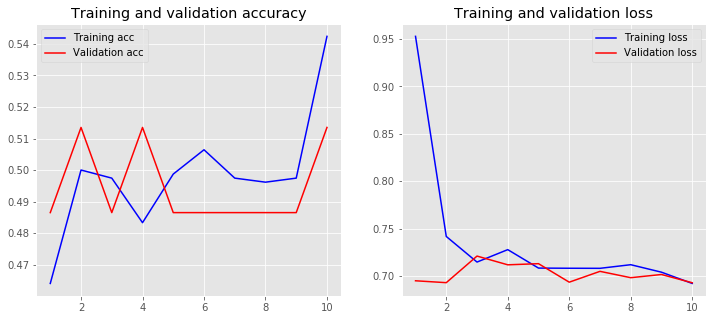

In [ ]:
loss, accuracy = loaded_train_test_model.evaluate(X_train, y_train, verbose=False)
print("Training Accuracy: {:.4f}".format(accuracy))
loss, accuracy = loaded_train_test_model.evaluate(X_test, y_test, verbose=False)
print("Testing Accuracy:  {:.4f}".format(accuracy))
plot_history(history)

In [ ]:
# clear_session()

# Model without first lstm layer

In [ ]:
def Model_without_first_lstm_layer():
    model_wihout_lstm = Sequential()

    model_wihout_lstm.add(layers.InputLayer(input_shape=first_layer_output[0].shape))
    model_wihout_lstm.add(Bidirectional(LSTM(units=32 , return_sequences=True)))

    # TextCNN with 4 conv layers
    model_wihout_lstm.add(Conv1D(128, 7, activation='tanh', input_shape=(None, 32)))
    model_wihout_lstm.add(Conv1D(128, 15, activation='tanh'))
    model_wihout_lstm.add(Conv1D(128, 25, activation='tanh'))
    model_wihout_lstm.add(Conv1D(128, 35, activation='tanh'))
    model_wihout_lstm.add(GlobalMaxPooling1D())
    model_wihout_lstm.add(Dense(64, activation='relu'))
    model_wihout_lstm.add(Dropout(0.2))
    model_wihout_lstm.add(Dense(1, activation='sigmoid'))
    model_wihout_lstm.compile(optimizer=myoptimizer,
                  loss=myloss,
                  metrics=[mymetrics])
    model_wihout_lstm.summary()
    return model_wihout_lstm

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
bidirectional_9 (Bidirection (None, 100, 64)           34048     
_________________________________________________________________
conv1d_20 (Conv1D)           (None, 94, 128)           57472     
_________________________________________________________________
conv1d_21 (Conv1D)           (None, 80, 128)           245888    
_________________________________________________________________
conv1d_22 (Conv1D)           (None, 56, 128)           409728    
_________________________________________________________________
conv1d_23 (Conv1D)           (None, 22, 128)           573568    
_________________________________________________________________
global_max_pooling1d_5 (Glob (None, 128)               0         
_________________________________________________________________
dense_10 (Dense)             (None, 64)               

In [ ]:
def fit_Model_without_first_lstm_layer():
    out_lstm_X_train, out_lstm_X_test, out_lstm_y_train, out_lstm_y_test = train_test_split(first_layer_output, y, test_size=0.25, random_state=1000)
    lX_train_List = chunking_data(out_lstm_X_train,9)
    ly_train_List = chunking_data(out_lstm_y_train,9)

    lX_test_List = chunking_data(out_lstm_X_test,9)
    ly_test_List = chunking_data(out_lstm_y_test,9)
    history = model_wihout_lstm.fit(lX_train_List[0], ly_train_List[0],
                        epochs=10,
                        verbose=False,
                        validation_data=(lX_test_List[0], ly_test_List[0]))
    model_wihout_lstm.save("model_wihout_lstm.h5")
    for i in range(1,len(X_train_List)-1):
        loaded_model_wihout_lstm = load_model("model_wihout_lstm.h5")
        loaded_model_wihout_lstm.fit(lX_train_List[i], ly_train_List[i],
                        epochs=10,
                        verbose=False,
                        validation_data=(lX_test_List[i], ly_test_List[i]))
        loaded_model_wihout_lstm.save("model_wihout_lstm.h5")
    return loaded_model_wihout_lstm , out_lstm_X_train, out_lstm_X_test, out_lstm_y_train, out_lstm_y_test , "model_wihout_lstm.h5" ,

In [ ]:
loaded_model_wihout_lstm , out_lstm_X_train, out_lstm_X_test, out_lstm_y_train, out_lstm_y_test , Cpath = fit_Model_without_first_lstm_layer()
# clear_session()

In [ ]:
evaluation(loaded_model_wihout_lstm,out_lstm_X_train,out_lstm_y_train,out_lstm_X_test,out_lstm_y_test)

Training Accuracy: 0.5036
Testing Accuracy:  0.4891


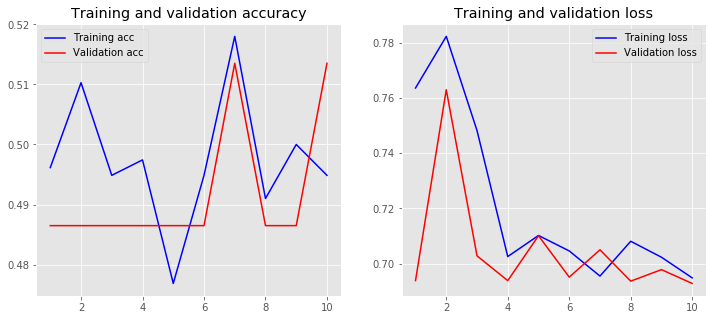

In [ ]:
loss, accuracy = loaded_model_wihout_lstm.evaluate(out_lstm_X_train, out_lstm_y_train, verbose=False)
print("Training Accuracy: {:.4f}".format(accuracy))
loss, accuracy = loaded_model_wihout_lstm.evaluate(out_lstm_X_test, out_lstm_y_test, verbose=False)
print("Testing Accuracy:  {:.4f}".format(accuracy))
plot_history(history)

# Training Accuracy: 0.5036
# Testing Accuracy:  0.4891